In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from zoneinfo import ZoneInfo


In [2]:
from pathlib import Path

UTC_TZ = ZoneInfo("UTC")
ARIZONA_TZ = ZoneInfo("America/Phoenix")

def convert_utc_to_arizona_index(df, timestamp_col="timestamp"):
    df = df.copy()

    if timestamp_col in df.columns:
        df[timestamp_col] = pd.to_datetime(df[timestamp_col], utc=True).dt.tz_convert(ARIZONA_TZ)
    else:
        df.index = pd.to_datetime(df.index, utc=True).tz_convert(ARIZONA_TZ)

    return df

# Use the processed file only to recover the expected column names.
df = pd.read_csv(
    "datasets/raw_data/INRIX_SPEED_AZ/processed/processed.csv",
    parse_dates=[0]
)
metadata_df = pd.read_csv("datasets/raw_data/INRIX_SPEED_AZ/metadata.csv")
sql_metadata_df = pd.read_csv("datasets/raw_data/INRIX_SPEED_AZ/sql_inrix_v3/metadata.csv")
sql_metadata_df = sql_metadata_df.rename(
    columns={
        "tmc_code": "Segment ID",
        "start_latitude": "Start Latitude",
        "start_longitude": "Start Longitude",
        "end_latitude": "End Latitude",
        "end_longitude": "End Longitude",
        "intersection_name": "Intersection",
        "road_name": "Road",
        "direction": "Direction",
    }
)
metadata_df = pd.concat([metadata_df, sql_metadata_df], ignore_index=True, sort=False)
metadata_df["segment_id"] = metadata_df["Segment ID"].astype(str)
segment_metadata = metadata_df.drop_duplicates("segment_id", keep="last").set_index("segment_id")
HARDCODED_SEGMENT_LABELS = {
    "1226260796": "Bullard Ave",
    "1226218849": "Bullard Ave",
    "1226233665": "Dysart Rd",
    "1226201492": "Dysart Rd",
    "1226264076": "75th Ave",
    "440907447": "75th Ave",
    "1226251131": "19th Ave",
    "1226251004": "19th Ave",
    "1226224154": "AZ-202 Loop",
    "1226229009": "AZ-202 Loop",
    "1226264043": "24th St",
    "448801792": "24th St",
    "448798652": "Ray Rd",
    "1226221569": "Ray Rd",
}
INCIDENT_TYPE_MARKERS = {
    1: "o",
    2: "s",
    3: "^",
    4: "D",
}
INCIDENT_TYPE_NAMES = {
    1: "Construction",
    2: "Events",
    3: "Congestion alerts",
    4: "Crashes and Hazards",
}

def format_segment_side_label(segment_id, named_labels=None):
    segment_key = str(segment_id)
    if segment_key in HARDCODED_SEGMENT_LABELS:
        return HARDCODED_SEGMENT_LABELS[segment_key]
    return ""

def build_segment_side_labels(segment_ids, named_labels=None):
    return [format_segment_side_label(segment_id, named_labels=named_labels) for segment_id in segment_ids]

# df = df.set_index("timestamp").sort_index() * 1.61

input_dir = Path("datasets/raw_data/INRIX_SPEED_AZ/processed")
reference_files = {
    f"out_{path.name.replace('input_', '')}": path
    for path in sorted(input_dir.glob("input_*.csv"))
}
eastward_segments = pd.read_csv(input_dir / "eastward.csv")["segment_id"].astype(str).tolist()
westward_segments = pd.read_csv(input_dir / "westward.csv")["segment_id"].astype(str).tolist()

incident_path = input_dir / "incidents.csv"
incident_df = pd.read_csv(incident_path, parse_dates=["timestamp"])
incident_df = convert_utc_to_arizona_index(incident_df, timestamp_col="timestamp")
incident_df = incident_df.set_index("timestamp").sort_index()

ref_dfs = {}
for output_file, ref_file in reference_files.items():
    ref_df = pd.read_csv(
        ref_file,
        header=None,
        parse_dates=[0]
    )
    ref_df.columns = df.columns
    ref_df = convert_utc_to_arizona_index(ref_df)
    ref_dfs[output_file] = ref_df.set_index("timestamp").sort_index() * 1.61

# ref_dfs["out_weekday1.csv"],max(axis=1)

In [3]:
ref_dfs["out_weekday1.csv"].head()

,122385153,123094133,440907446,440907447,448798645,448798652,448801792,450124719,450136781,450178140,...,1226274258,1226274301,1226274364,1226276233,1226278116,1226278118,1226278270,1226278279,1226278747,1626426438
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-06-23 17:00:00-07:00,65.892154,19.891971,46.621807,67.757026,69.000274,68.378650,69.000274,23.621715,19.270347,29.837956,...,59.054289,32.324453,61.540785,67.135402,71.486770,70.865146,19.270347,64.648905,68.378650,67.757026
2025-06-23 17:05:00-07:00,69.621898,24.864964,37.297445,69.000274,68.378650,70.243522,69.621898,24.243340,24.864964,28.594708,...,60.297537,54.702920,63.405657,69.000274,70.865146,70.865146,24.243340,66.513778,69.000274,68.378650
2025-06-23 17:10:00-07:00,68.378650,31.081205,47.865055,67.135402,67.757026,68.378650,68.378650,23.000091,20.513595,36.054197,...,60.297537,59.675913,60.297537,69.000274,69.621898,68.378650,24.243340,63.405657,67.135402,64.027281
2025-06-23 17:15:00-07:00,70.865146,32.946077,54.081296,65.892154,71.486770,66.513778,67.757026,32.324453,26.729836,32.324453,...,57.811040,46.621807,60.919161,67.135402,69.000274,70.865146,19.891971,59.675913,68.378650,66.513778
2025-06-23 17:20:00-07:00,67.757026,23.621715,52.838048,68.378650,73.351643,69.000274,68.378650,33.567701,32.324453,32.324453,...,49.108303,34.189325,62.784033,68.378650,72.108395,72.108395,25.486588,28.594708,67.135402,66.513778


In [4]:
output_dir = Path("exp1_gwnet")
output_files = {
    output_file: output_dir / output_file
    for output_file in reference_files
    if (output_dir / output_file).exists()
}

aligned_outputs = {}
aligned_incidents = {}

for output_file, output_path in output_files.items():
    ref_df = ref_dfs[output_file]
    df = pd.read_csv(output_path, header=None, parse_dates=[0])
    df.columns = ref_df.reset_index().columns
    df = convert_utc_to_arizona_index(df, timestamp_col=df.columns[0])
    df = df.set_index(df.columns[0]).sort_index() * 1.61
    
    df_aligned = df.reindex(ref_df.index)
    
    # offset by 5 mins
    # df_aligned.index = df_aligned.index - pd.Timedelta(minutes=5)
    
    aligned_outputs[output_file] = df_aligned
    aligned_incidents[output_file] = incident_df.reindex(ref_df.index).fillna(0)

In [5]:
def plot_segment_predictions(
    segment_id,
    output_file,
    start=None,
    end=None,
    date_range=None,
    n_points=None,
    interval=3,
):
    """
    Plot predictions vs ground truth for a segment.

    Parameters
    ----------
    segment_id : str
    start : str or datetime, optional
        Start date for subset
    end : str or datetime, optional
        End date for subset
    date_range : tuple[str | datetime, str | datetime], optional
        Convenience alias for (start, end)
    n_points : int, optional
        Plot only last N timestamps after date filtering
    """

    ref_df = ref_dfs[output_file]

    # Ground truth
    dfs = [
        ref_df[[segment_id]].rename(columns={segment_id: "Ground Truth"})
    ]

    # Add model predictions
    df = aligned_outputs[output_file]
    # model_name = output_file.replace("out_", "").replace(".csv", "")
    dfs.append(df[[segment_id]].rename(columns={segment_id: "Prediction"}))

    # Align and clean
    combined = pd.concat(dfs, axis=1, join="inner").dropna()

    # ---- Subset logic ----
    if date_range is not None:
        if len(date_range) != 2:
            raise ValueError("date_range must be a (start, end) pair.")
        start, end = date_range

    if start is not None or end is not None:
        start_ts = pd.Timestamp(start) if start is not None else None
        end_ts = pd.Timestamp(end) if end is not None else None

        if start_ts is not None and start_ts.tzinfo is None:
            start_ts = start_ts.tz_localize(ARIZONA_TZ)
        if end_ts is not None and end_ts.tzinfo is None:
            end_ts = end_ts.tz_localize(ARIZONA_TZ)

        combined = combined.loc[start_ts:end_ts]

    if n_points:
        combined = combined.tail(n_points)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))

    for col in combined.columns:
        ax.plot(combined.index, combined[col], label=col)

    ax.set_xlabel("Date")
    ax.set_ylabel("Speed (mph)")
    ax.set_title(f"Segment {segment_id}: Prediction vs Ground Truth")
    ax.legend()


    ax.xaxis.set_major_locator(mdates.HourLocator(interval=interval, tz=ARIZONA_TZ))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %m-%d %H:%M", tz=ARIZONA_TZ))

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return combined

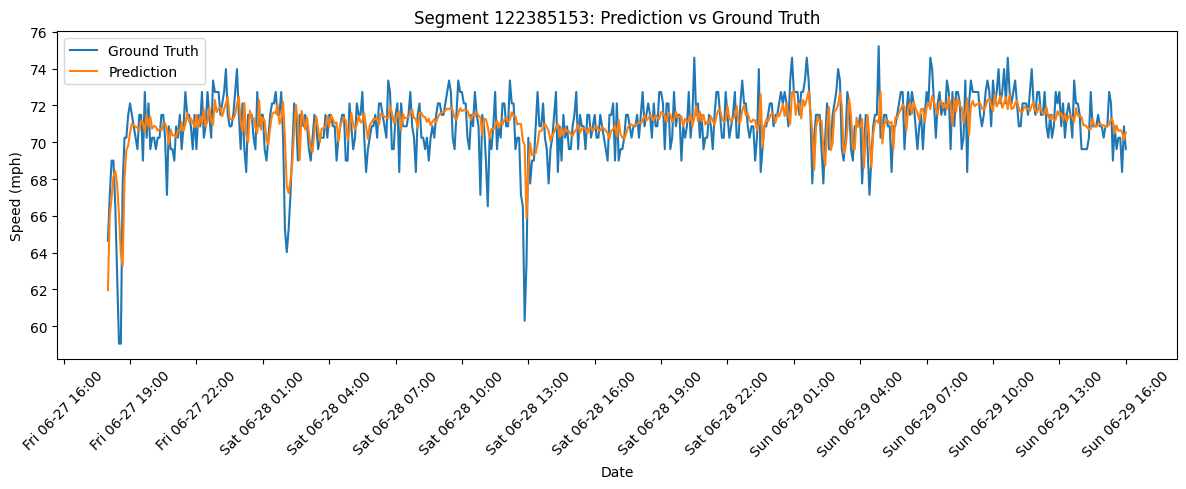

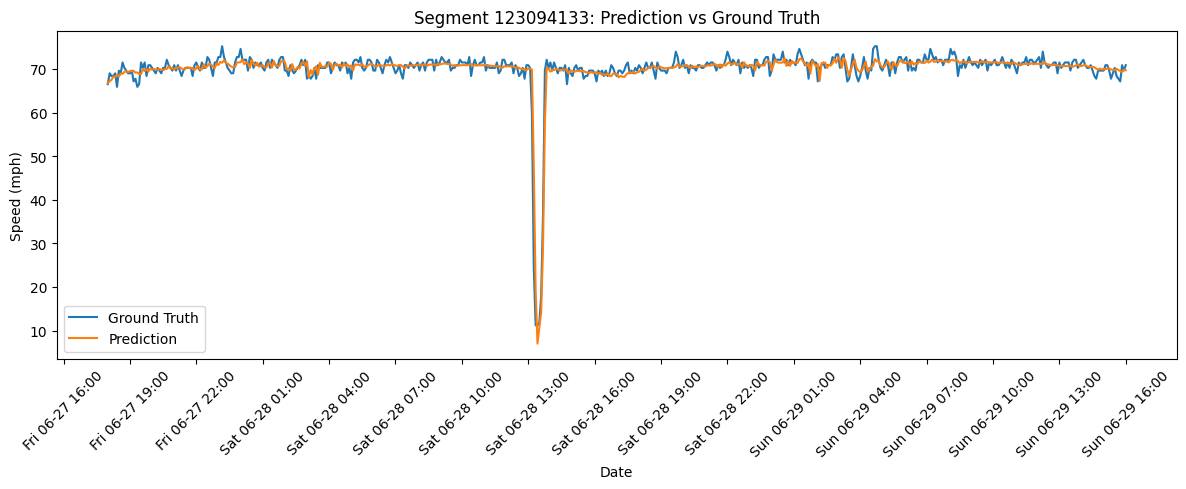

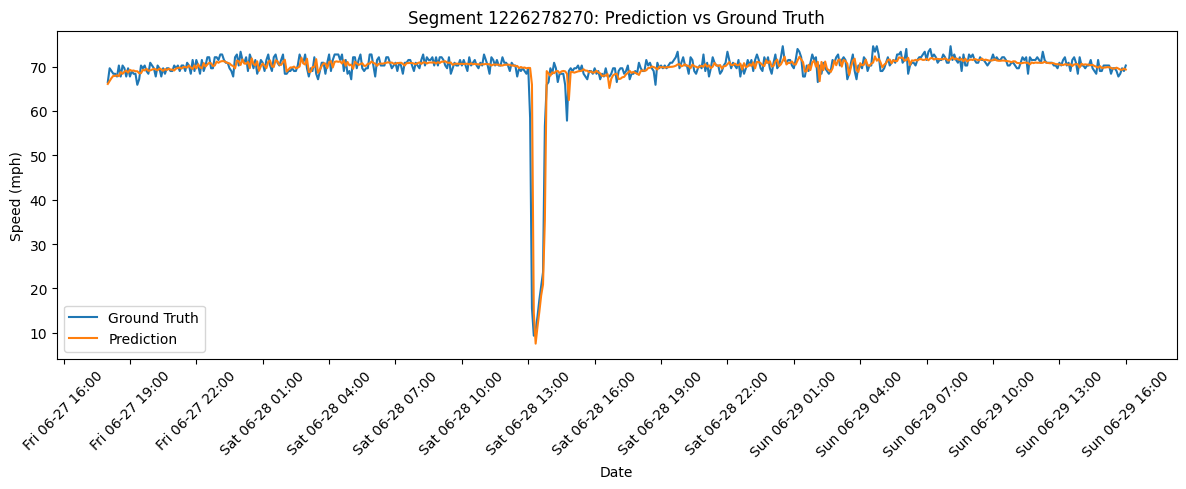

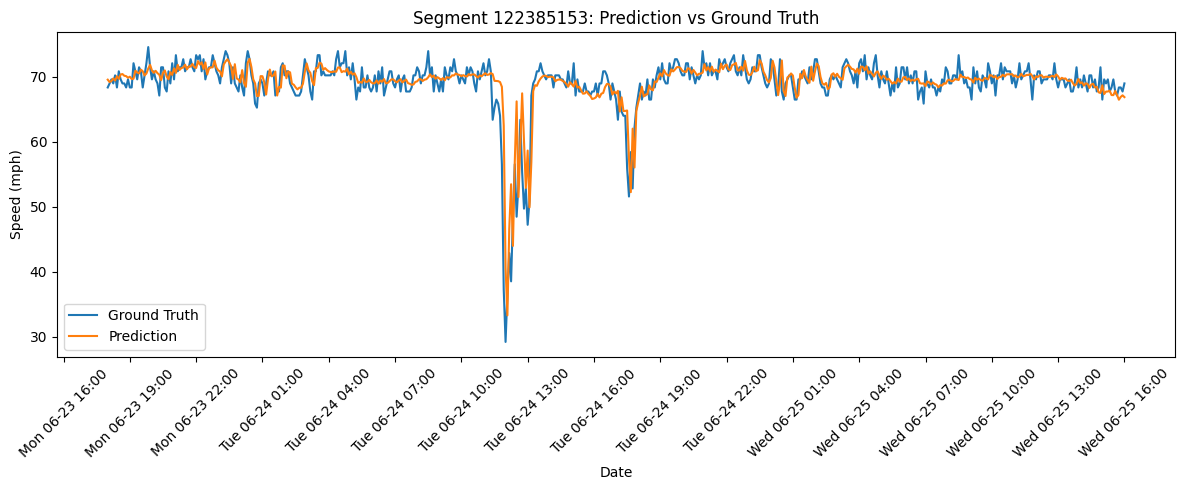

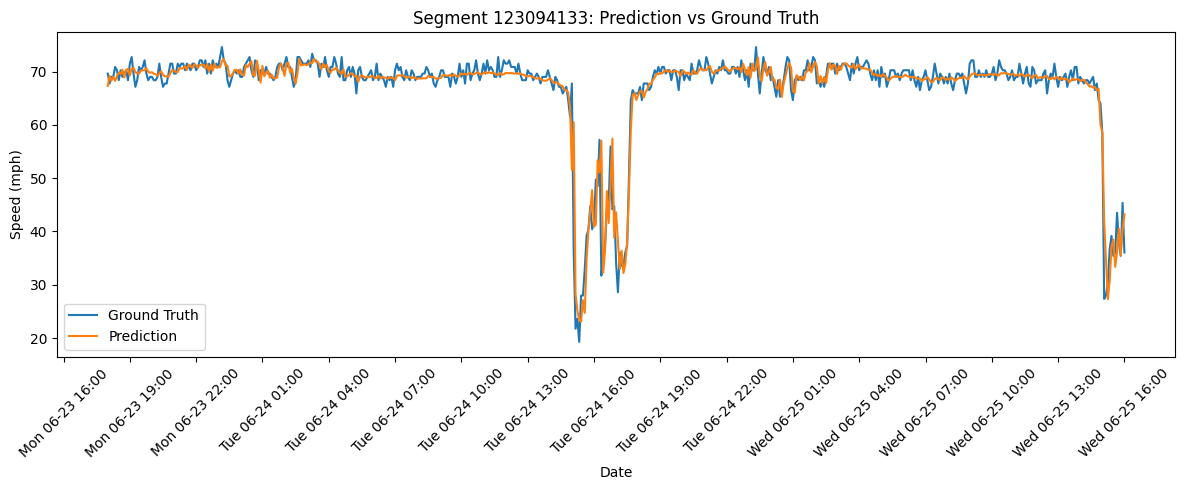

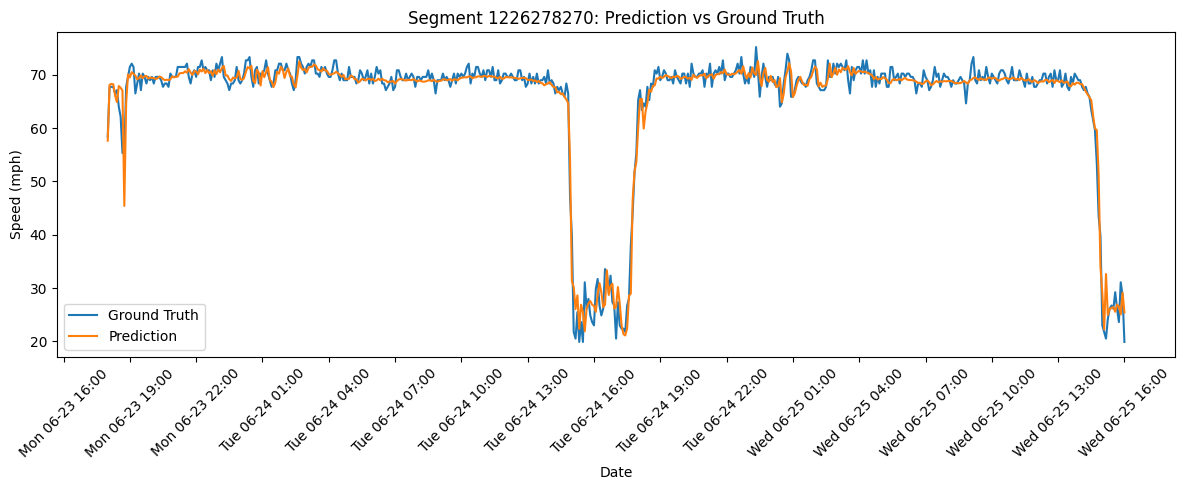

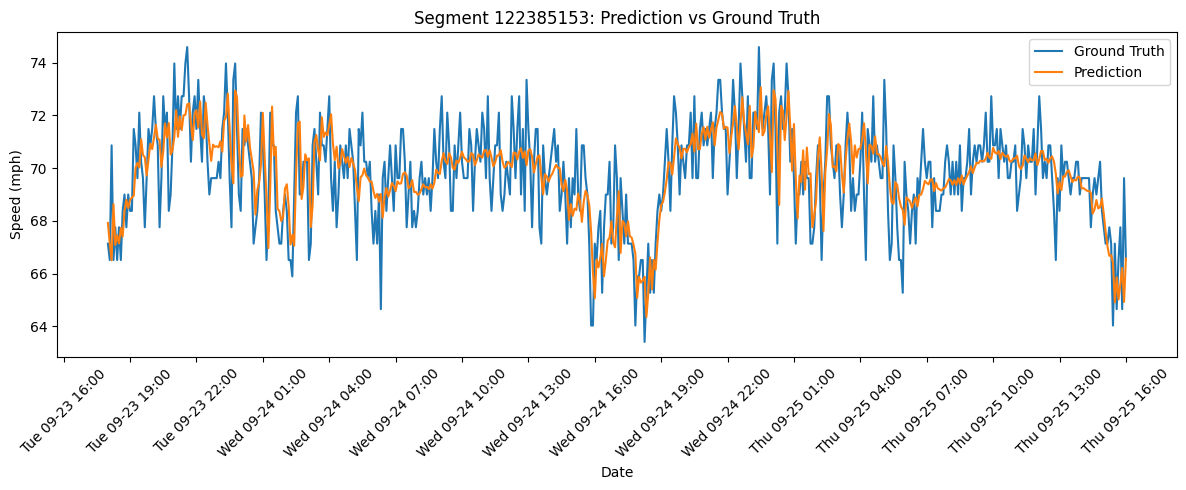

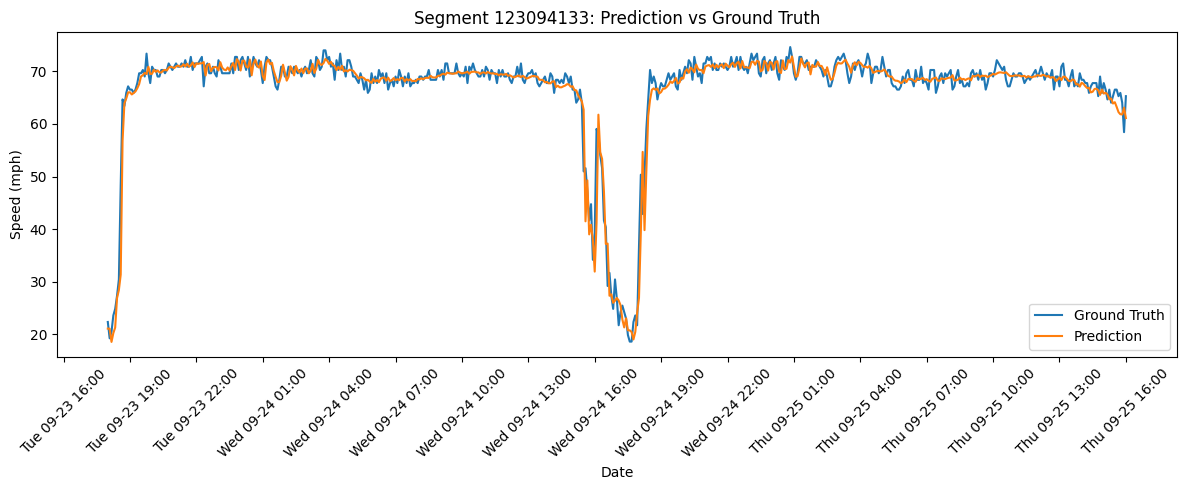

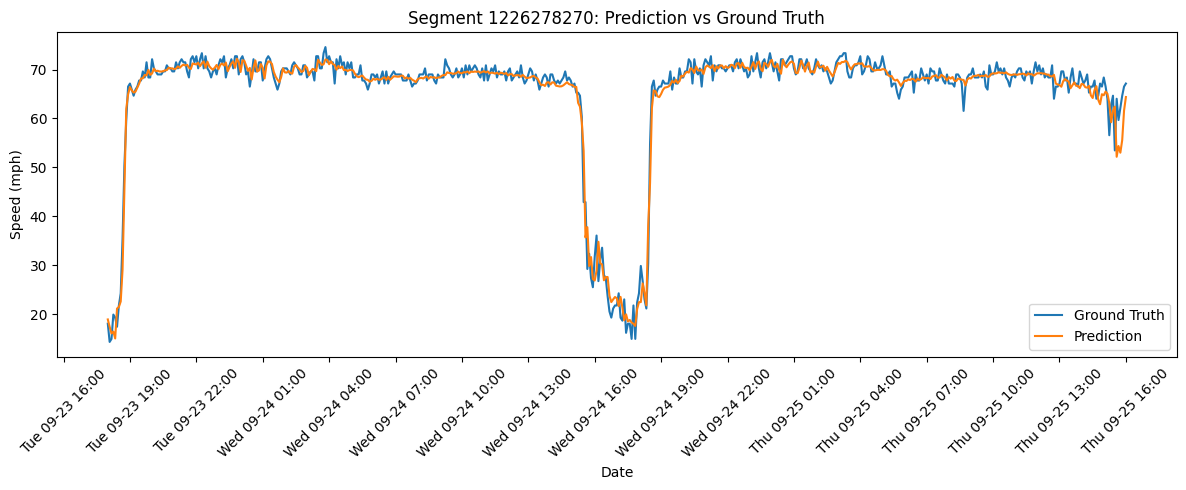

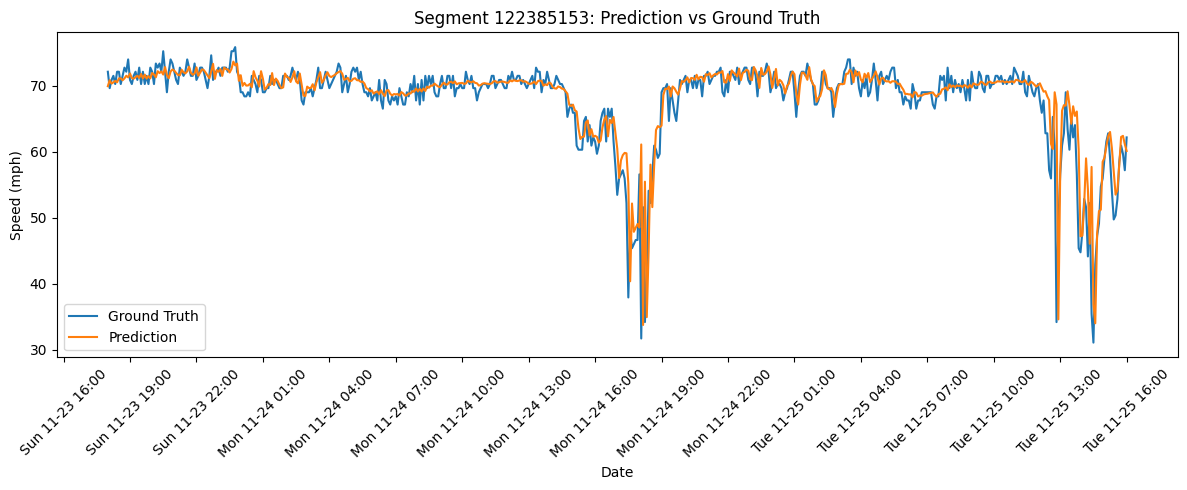

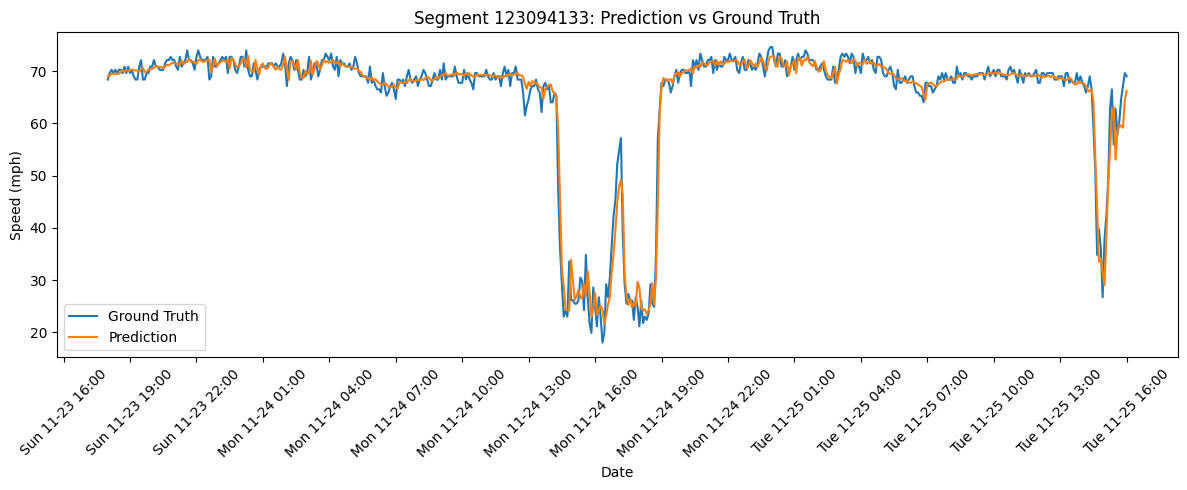

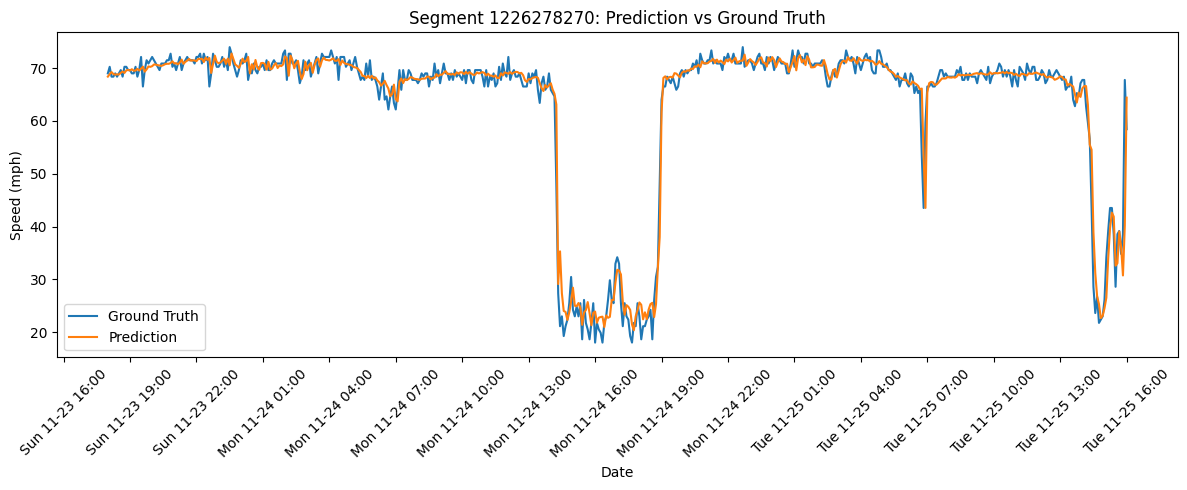

In [6]:
segments = [
    "122385153",
    "123094133",
    "1226278270",
]

for output_file in output_files:
    for segment in segments:
        plot_segment_predictions(
            segment_id=segment, 
            output_file=output_file,
            # date_range=("2025-06-28 10:00", "2025-06-28 18:00"),
            interval=3
        )

In [7]:
def plot_segments_heatmap(
    output_file,
    view="absolute_error",
    start=None,
    end=None,
    n_points=None,
    columns=None,
    title_suffix=None,
    named_labels=None,
    figsize=(18, 10),
    cmap=None,
):
    """
    Plot all segments at once as a heatmap for one output file.

    Parameters
    ----------
    output_file : str
        Output prediction file to visualize.
    view : str
        One of: 'ground_truth', 'prediction', 'error', 'absolute_error'.
    start, end : str or datetime, optional
        Time range for subsetting.
    n_points : int, optional
        Plot only the last N timestamps.
    columns : sequence, optional
        Explicit segment subset/order to use on the heatmap.
    title_suffix : str, optional
        Extra text appended to the heatmap title, such as 'Eastward' or 'Westward'.
    named_labels : sequence[str], optional
        Labels to show on the y-axis when matched in metadata; all other labels stay blank.
    """

    ref_df = ref_dfs[output_file]
    pred_df = aligned_outputs[output_file]
    incident_df = aligned_incidents[output_file]

    combined = pred_df.reindex(ref_df.index)

    if start or end:
        ref_df = ref_df.loc[start:end]
        combined = combined.loc[start:end]
        incident_df = incident_df.loc[start:end]

    if n_points:
        ref_df = ref_df.tail(n_points)
        combined = combined.tail(n_points)
        incident_df = incident_df.tail(n_points)

    valid_columns = ref_df.columns.intersection(combined.columns).intersection(incident_df.columns)

    if columns is not None:
        requested_columns = [column for column in columns if column in valid_columns]
    else:
        requested_columns = list(valid_columns)

    if not requested_columns:
        raise ValueError("No requested segments are available for this heatmap.")

    heatmap_columns = requested_columns

    ground_truth = ref_df[heatmap_columns]
    prediction = combined[heatmap_columns]

    data_options = {
        "ground_truth": ground_truth,
        "prediction": prediction,
        "error": prediction - ground_truth,
        "absolute_error": (prediction - ground_truth).abs(),
    }

    if view not in data_options:
        raise ValueError("view must be one of: 'ground_truth', 'prediction', 'error', 'absolute_error'")

    plot_df = data_options[view].dropna(axis=0, how="all").dropna(axis=1, how="all")
    heatmap_df = plot_df.T
    incident_plot_df = incident_df.reindex(index=plot_df.index, columns=plot_df.columns).fillna(0)

    if cmap is None:
        cmap = "coolwarm" if view == "error" else "plasma"

    segment_labels = build_segment_side_labels(heatmap_df.index, named_labels=named_labels)
    title = "I-10 Corridor Heatmap"
    if title_suffix:
        title = f"{title} ({title_suffix})"

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        heatmap_df,
        cmap=cmap,
        center=0 if view == "error" else None,
        cbar_kws={"label": view.replace("_", " ").title()},
        yticklabels=segment_labels,
        ax=ax,
    )

    incident_values = incident_plot_df.T.to_numpy()
    incident_active = incident_values.gt(0) if hasattr(incident_values, "gt") else (incident_values > 0)
    prev_inactive = np.concatenate(
        [np.ones((incident_active.shape[0], 1), dtype=bool), ~incident_active[:, :-1]],
        axis=1,
    )
    next_inactive = np.concatenate(
        [~incident_active[:, 1:], np.ones((incident_active.shape[0], 1), dtype=bool)],
        axis=1,
    )
    incident_start_mask = incident_active & prev_inactive
    incident_end_mask = incident_active & next_inactive

    start_y, start_x = np.where(incident_start_mask)
    end_y, end_x = np.where(incident_end_mask)
    start_types = incident_values[start_y, start_x].astype(int) if len(start_x) else np.array([], dtype=int)
    end_types = incident_values[end_y, end_x].astype(int) if len(end_x) else np.array([], dtype=int)

    incident_marker_color = "#276D31"
    legend_handles = []
    for incident_type, marker in INCIDENT_TYPE_MARKERS.items():
        start_mask = start_types == incident_type
        if start_mask.any():
            ax.scatter(
                start_x[start_mask] + 0.5,
                start_y[start_mask] + 0.5,
                s=240,
                c=incident_marker_color,
                marker=marker,
                edgecolors="white",
                linewidths=0.8,
                zorder=4,
            )
            incident_label = INCIDENT_TYPE_NAMES.get(incident_type, f"Type {incident_type}")
            legend_handles.append(
                Line2D(
                    [0], [0],
                    marker=marker,
                    color="w",
                    markerfacecolor=incident_marker_color,
                    markeredgecolor="white",
                    markeredgewidth=0.6,
                    markersize=14,
                    linestyle="None",
                    label=f"{incident_label} start",
                )
            )
        end_mask = end_types == incident_type
        if end_mask.any():
            ax.scatter(
                end_x[end_mask] + 0.5,
                end_y[end_mask] + 0.5,
                s=150,
                facecolors="none",
                edgecolors=incident_marker_color,
                marker=marker,
                linewidths=2.0,
                zorder=4,
            )
            incident_label = INCIDENT_TYPE_NAMES.get(incident_type, f"Type {incident_type}")
            legend_handles.append(
                Line2D(
                    [0], [0],
                    marker=marker,
                    color="w",
                    markerfacecolor="none",
                    markeredgecolor=incident_marker_color,
                    markeredgewidth=1.6,
                    markersize=14,
                    linestyle="None",
                    label=f"{incident_label} end",
                )
            )
    if legend_handles:
        ax.legend(handles=legend_handles, loc="upper right", fontsize=22)

    step = max(1, len(plot_df.index) // 20)
    xtick_positions = list(range(0, len(plot_df.index), step))
    xtick_labels = [plot_df.index[i].tz_convert(ARIZONA_TZ).strftime("%a %m-%d %H:%M") for i in xtick_positions]
    ax.set_xticks([i + 0.5 for i in xtick_positions])
    ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=18)

    ax.set_xlabel("Timestamp", fontsize=22)
    ax.set_ylabel("Intersection", fontsize=22)
    ax.tick_params(axis="y", labelsize=26)
    ax.set_title(title, fontsize=26)
    fig.subplots_adjust(left=0.33)
    plt.tight_layout()
    plt.show()

    return plot_df


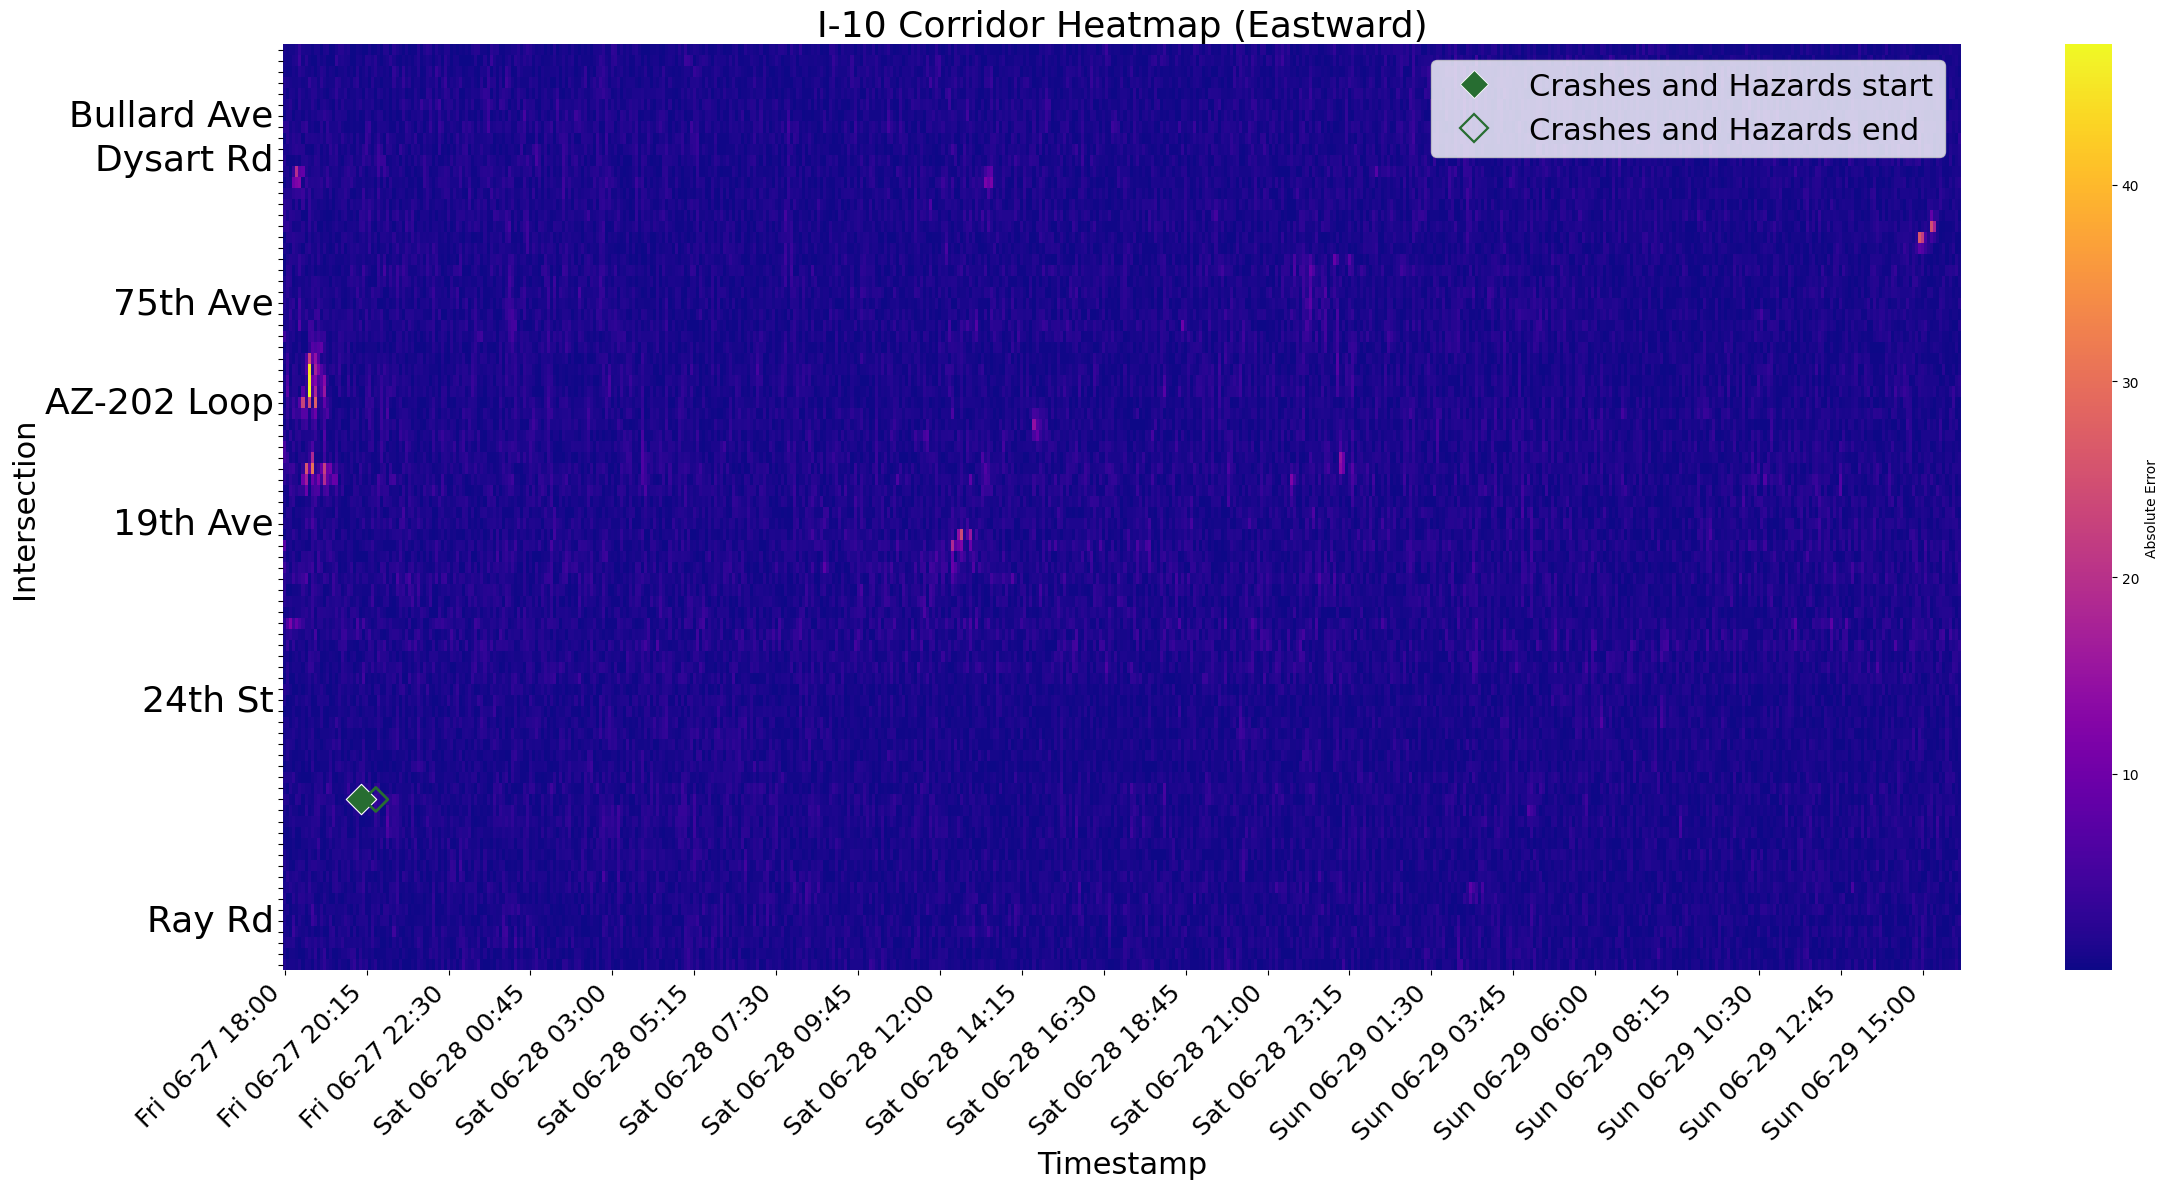

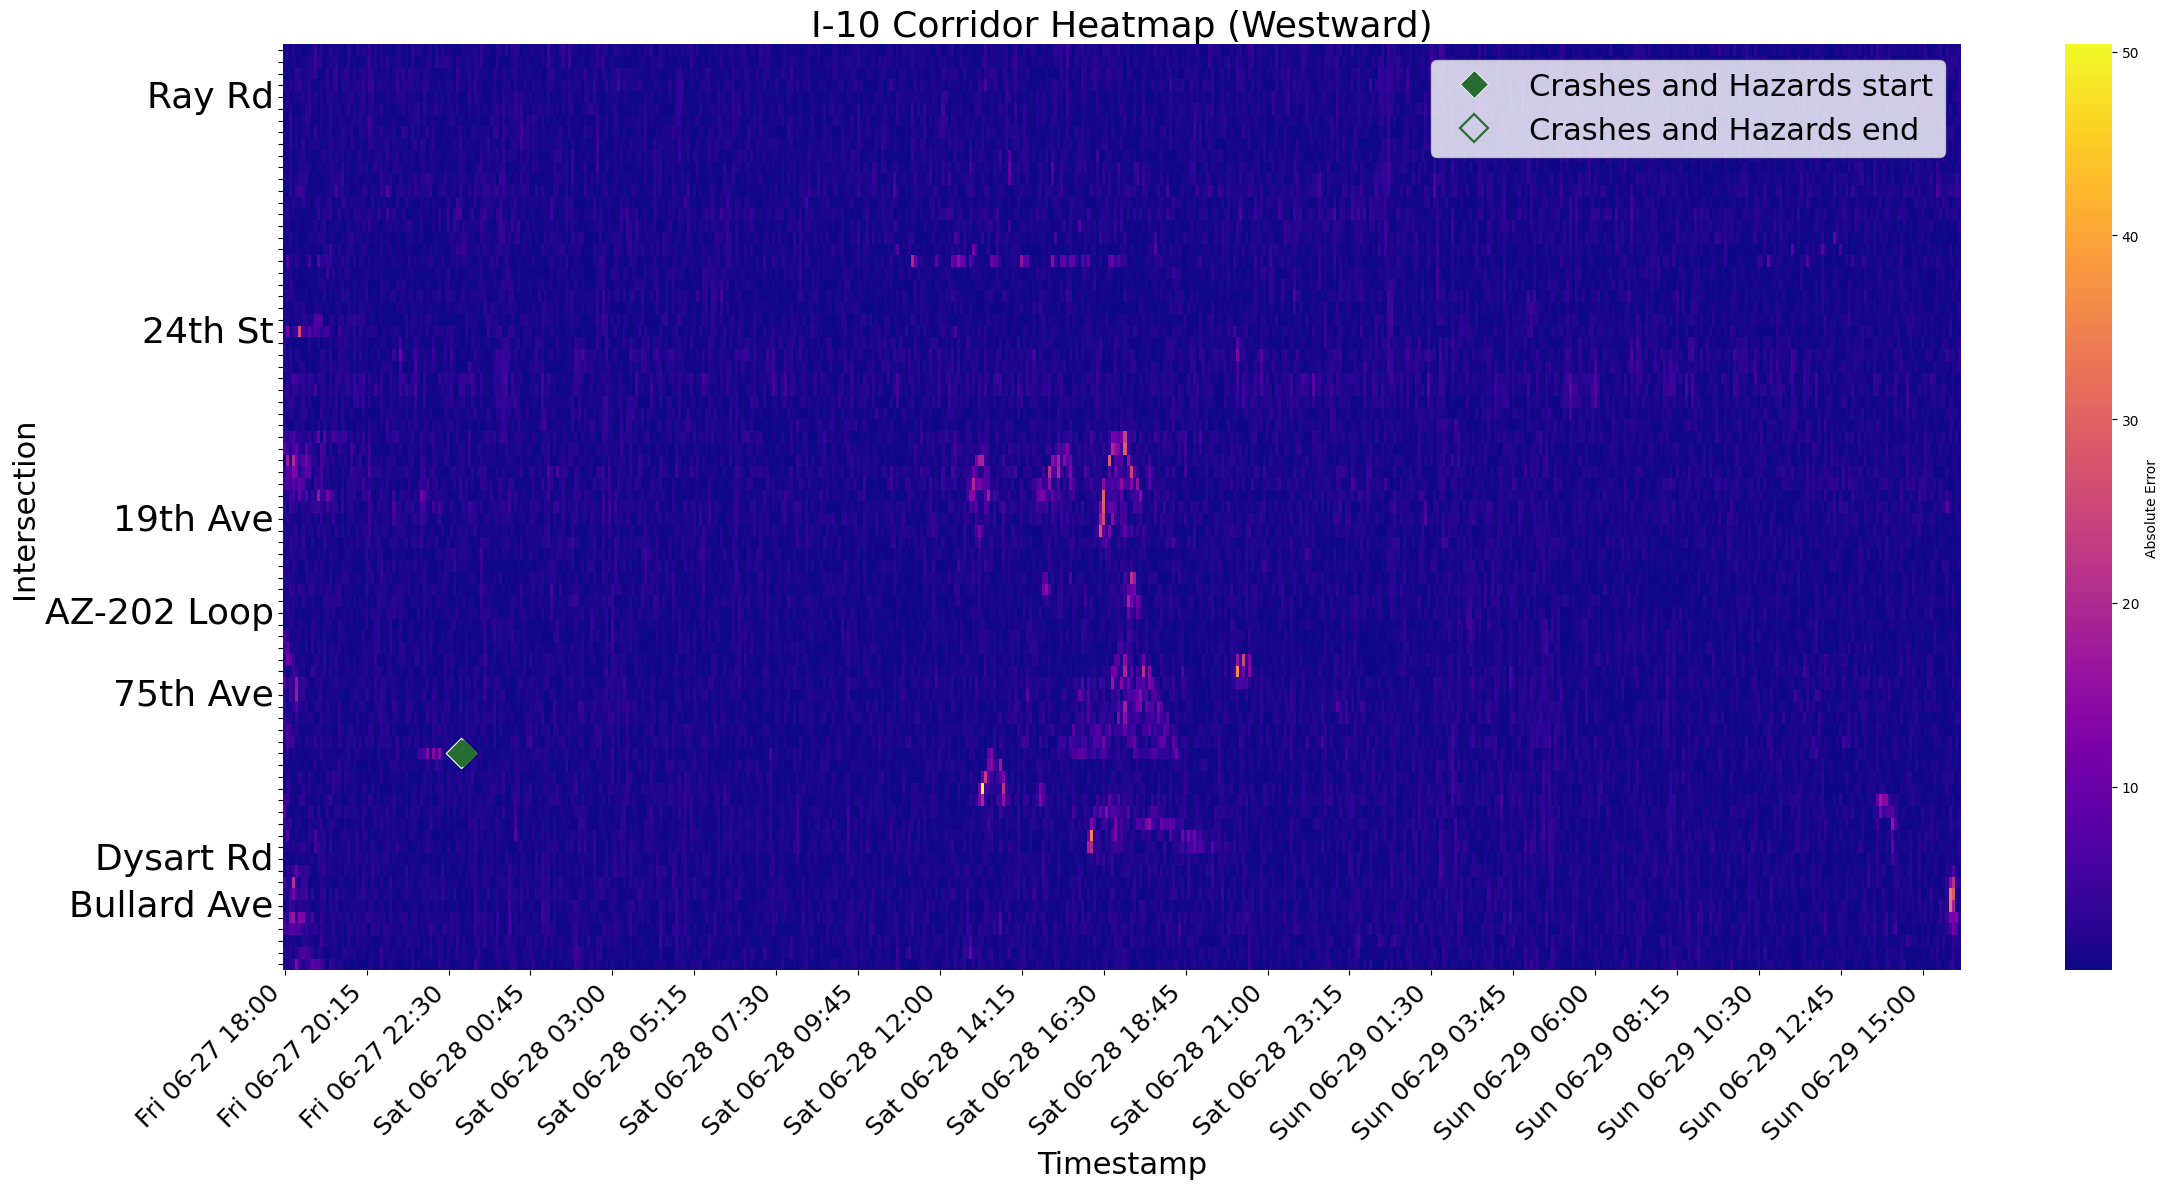

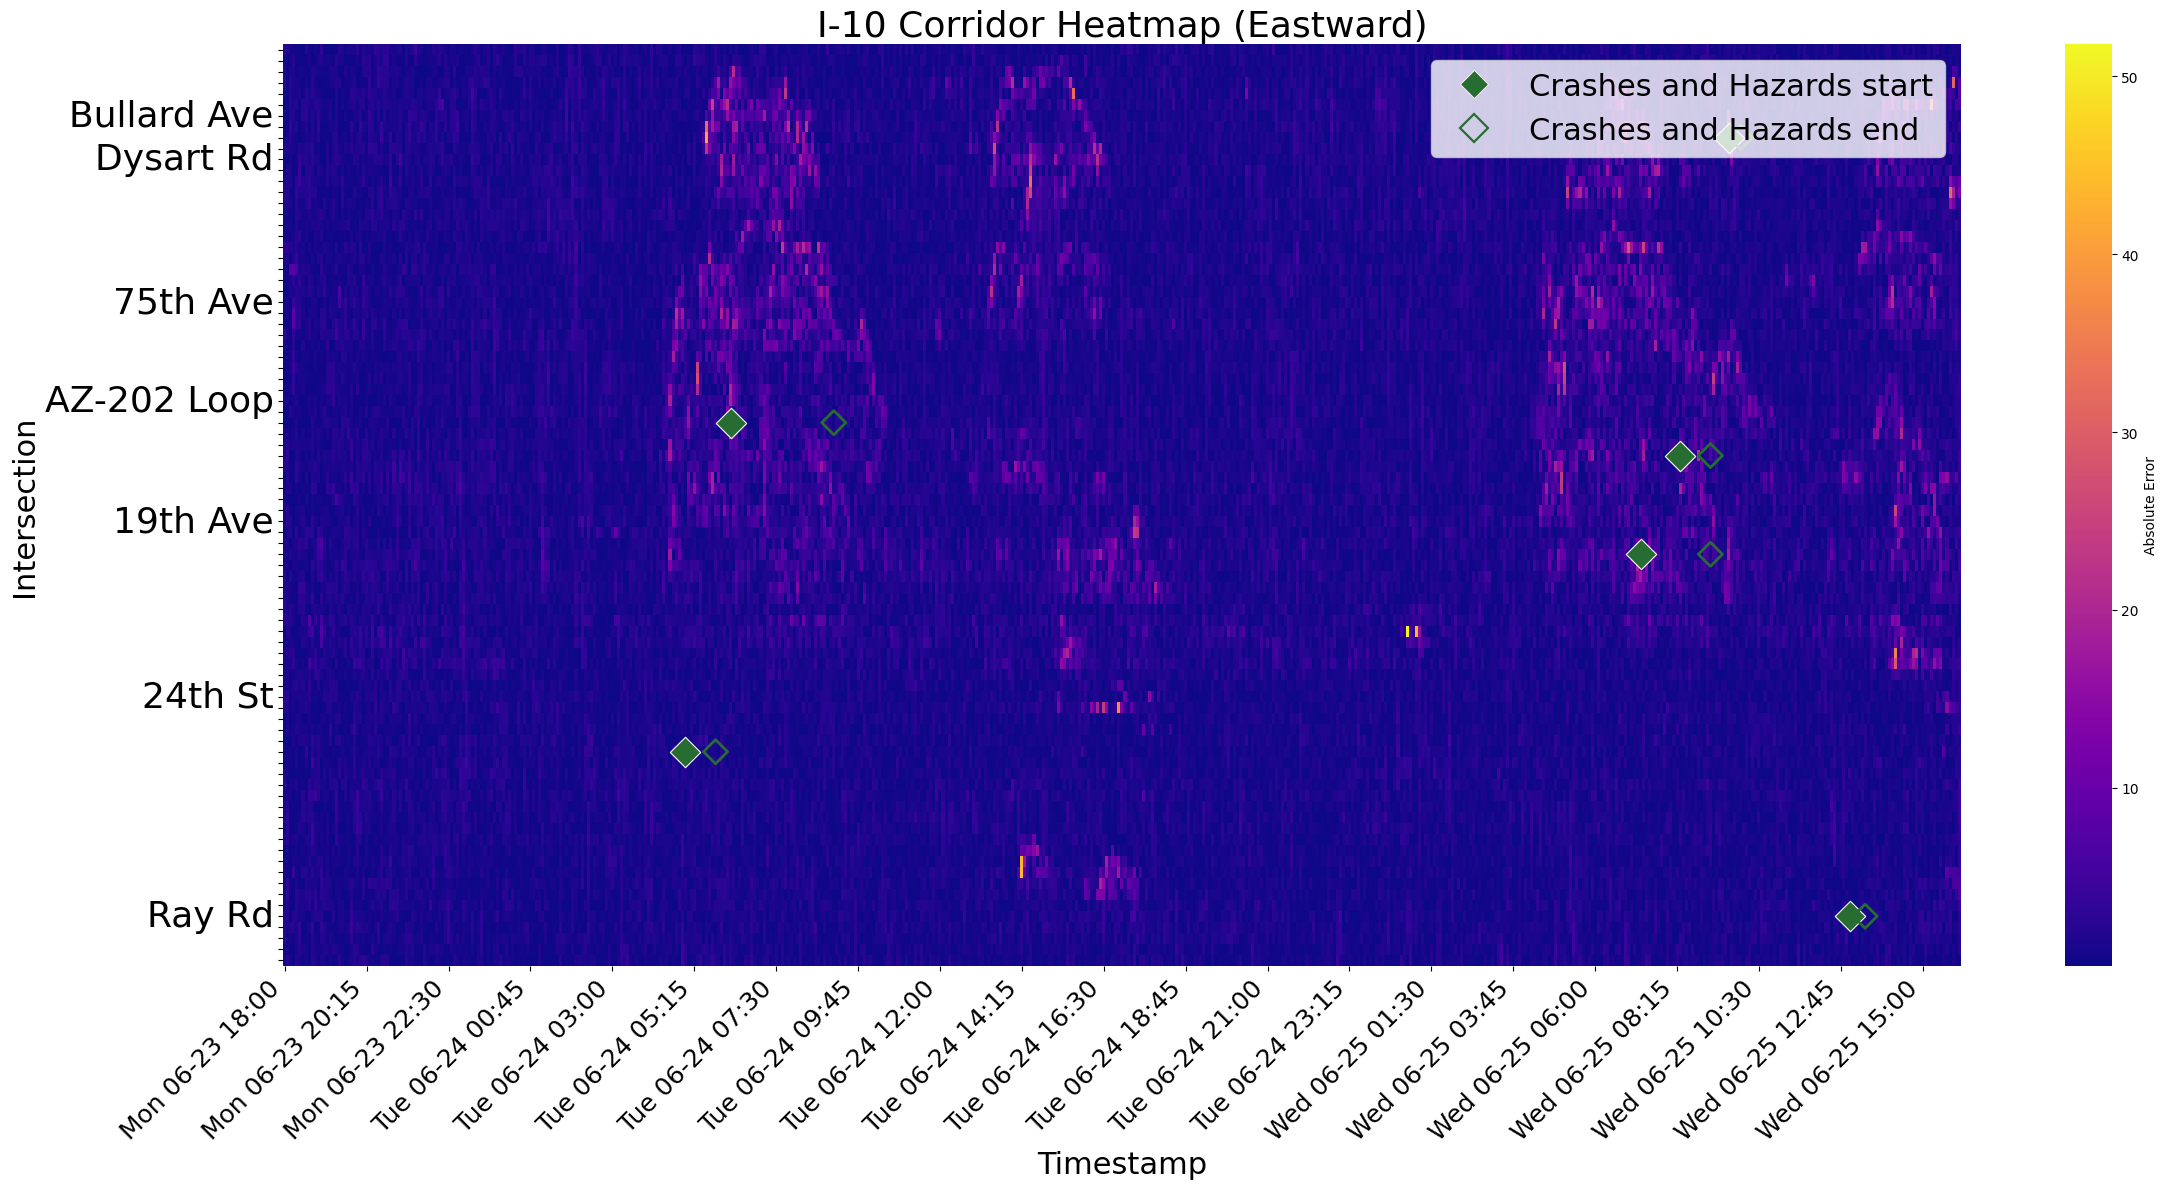

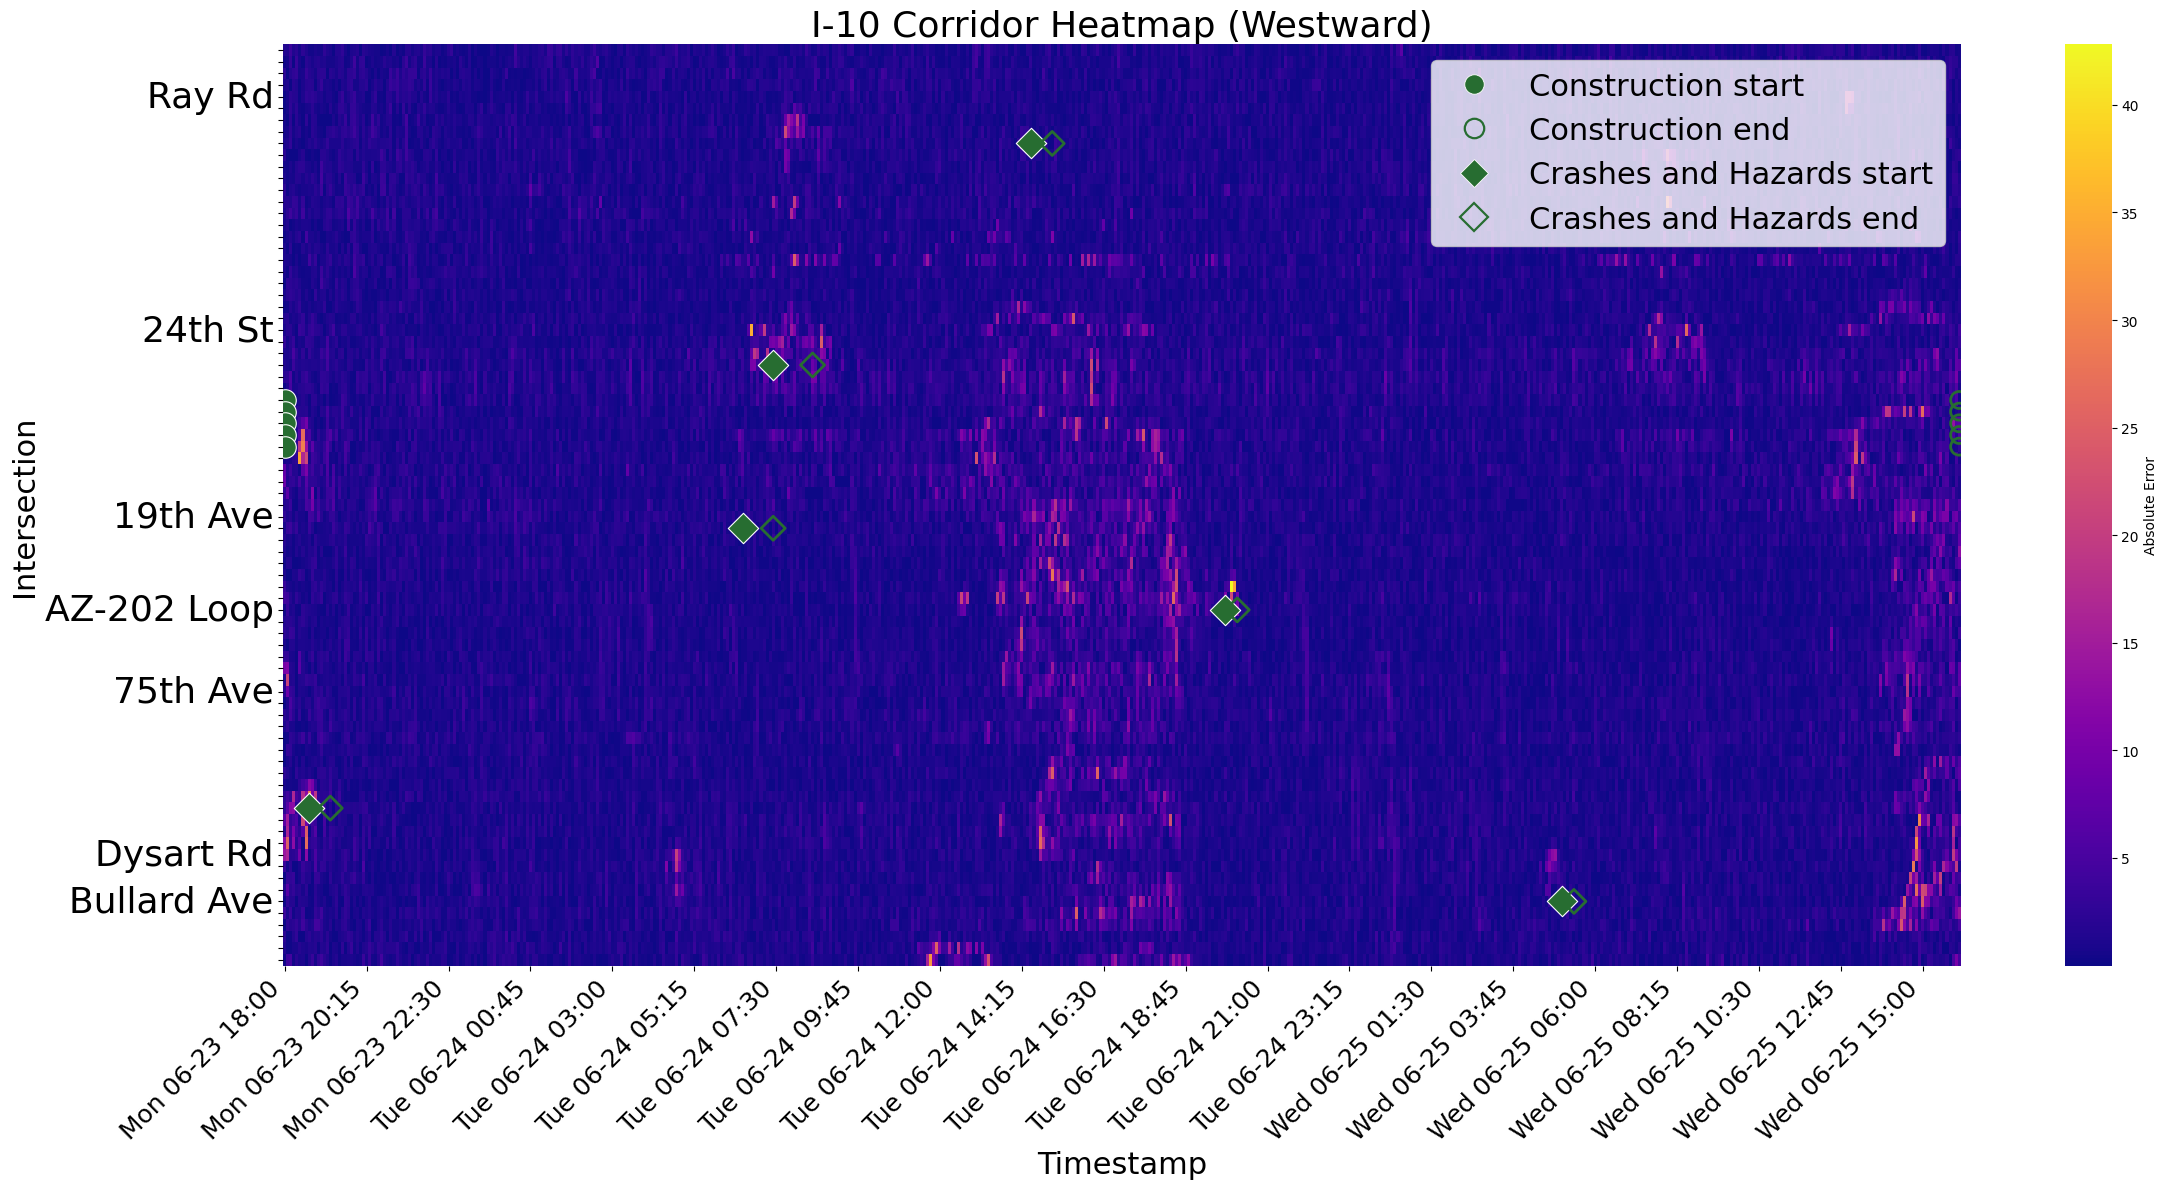

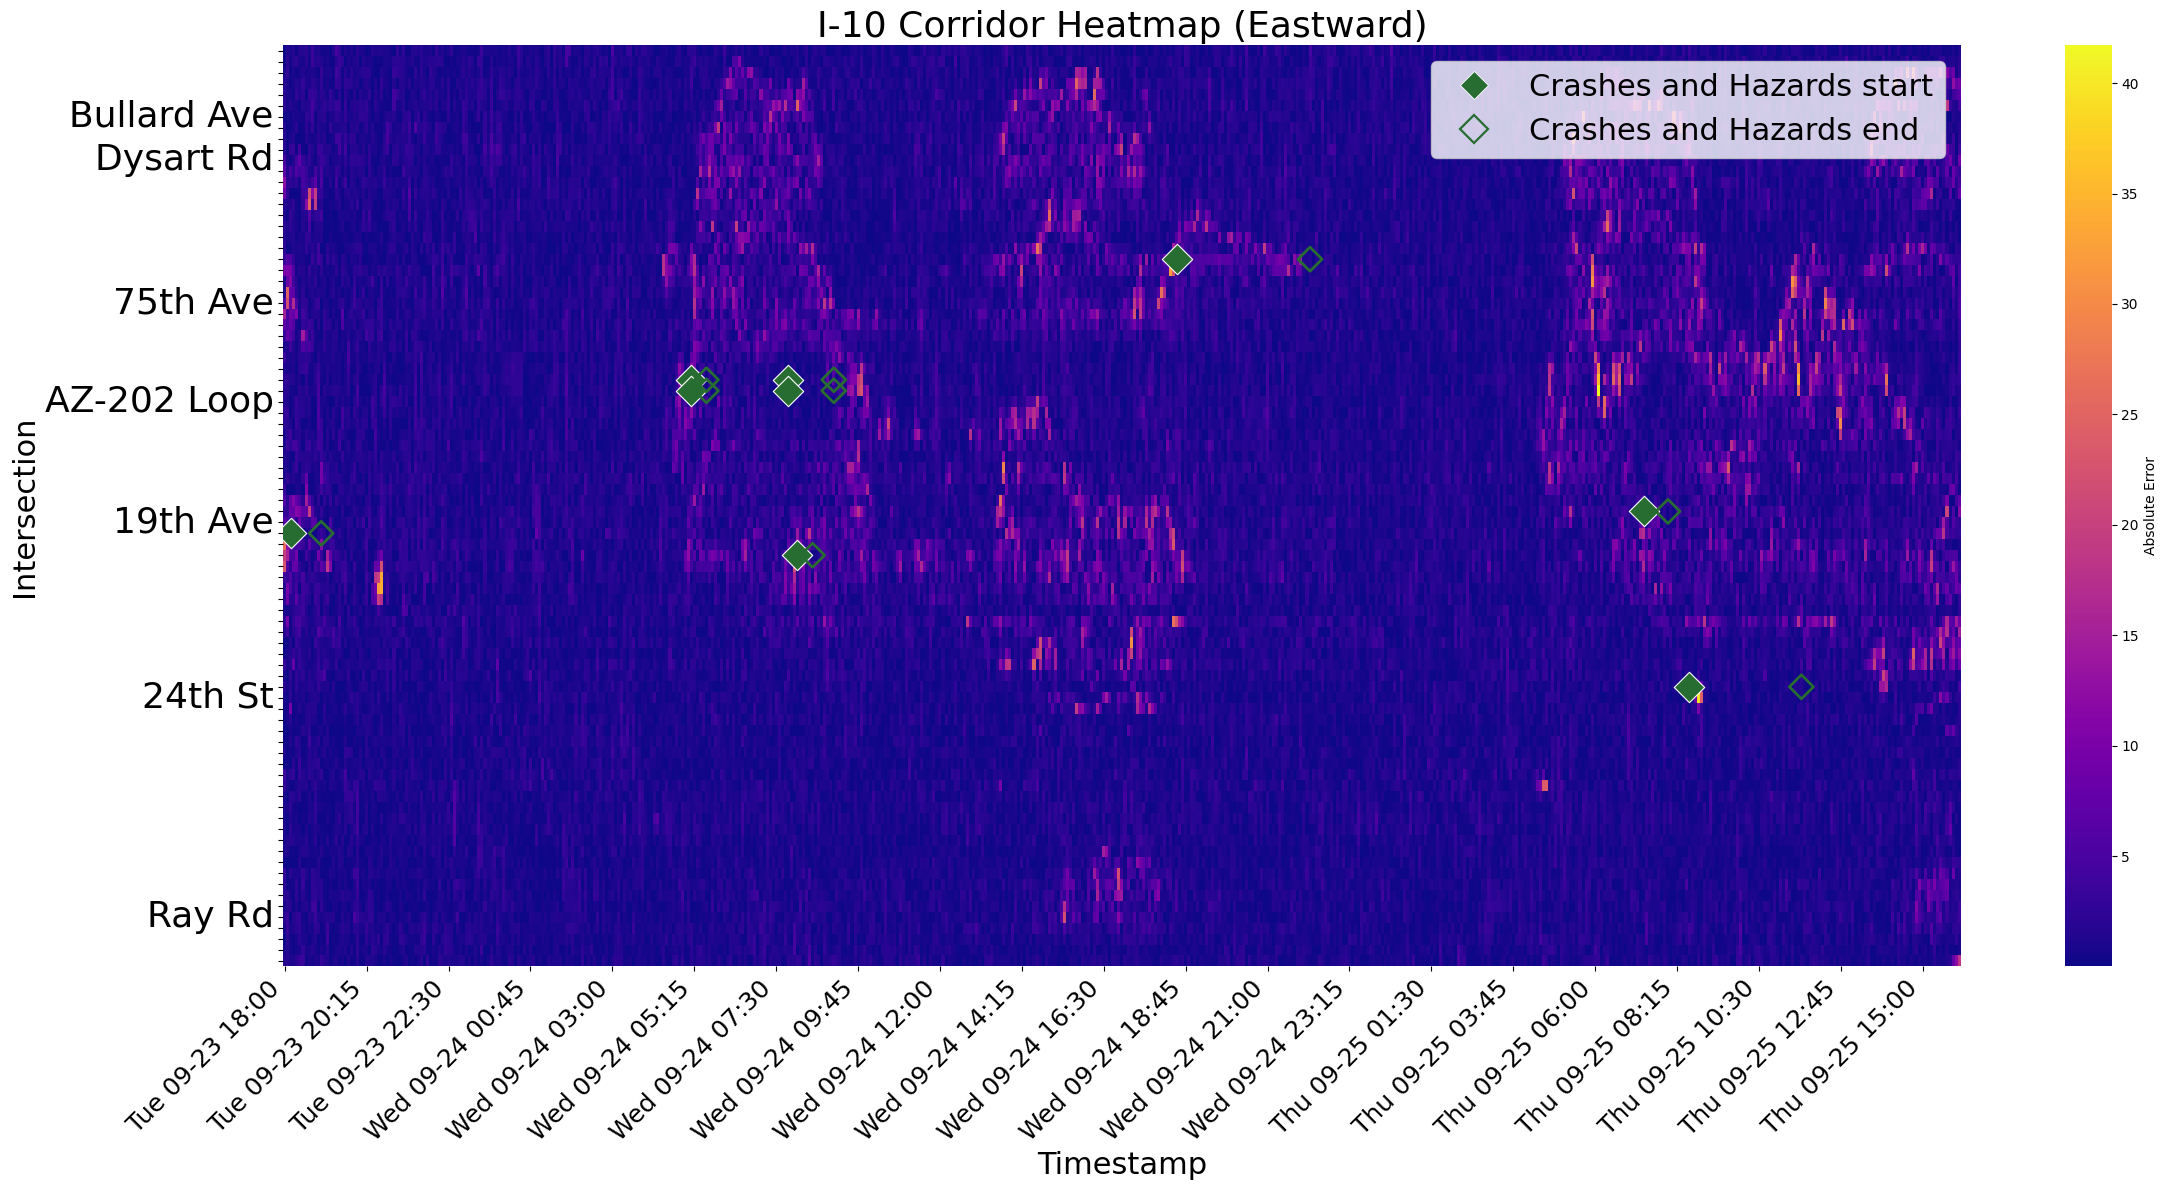

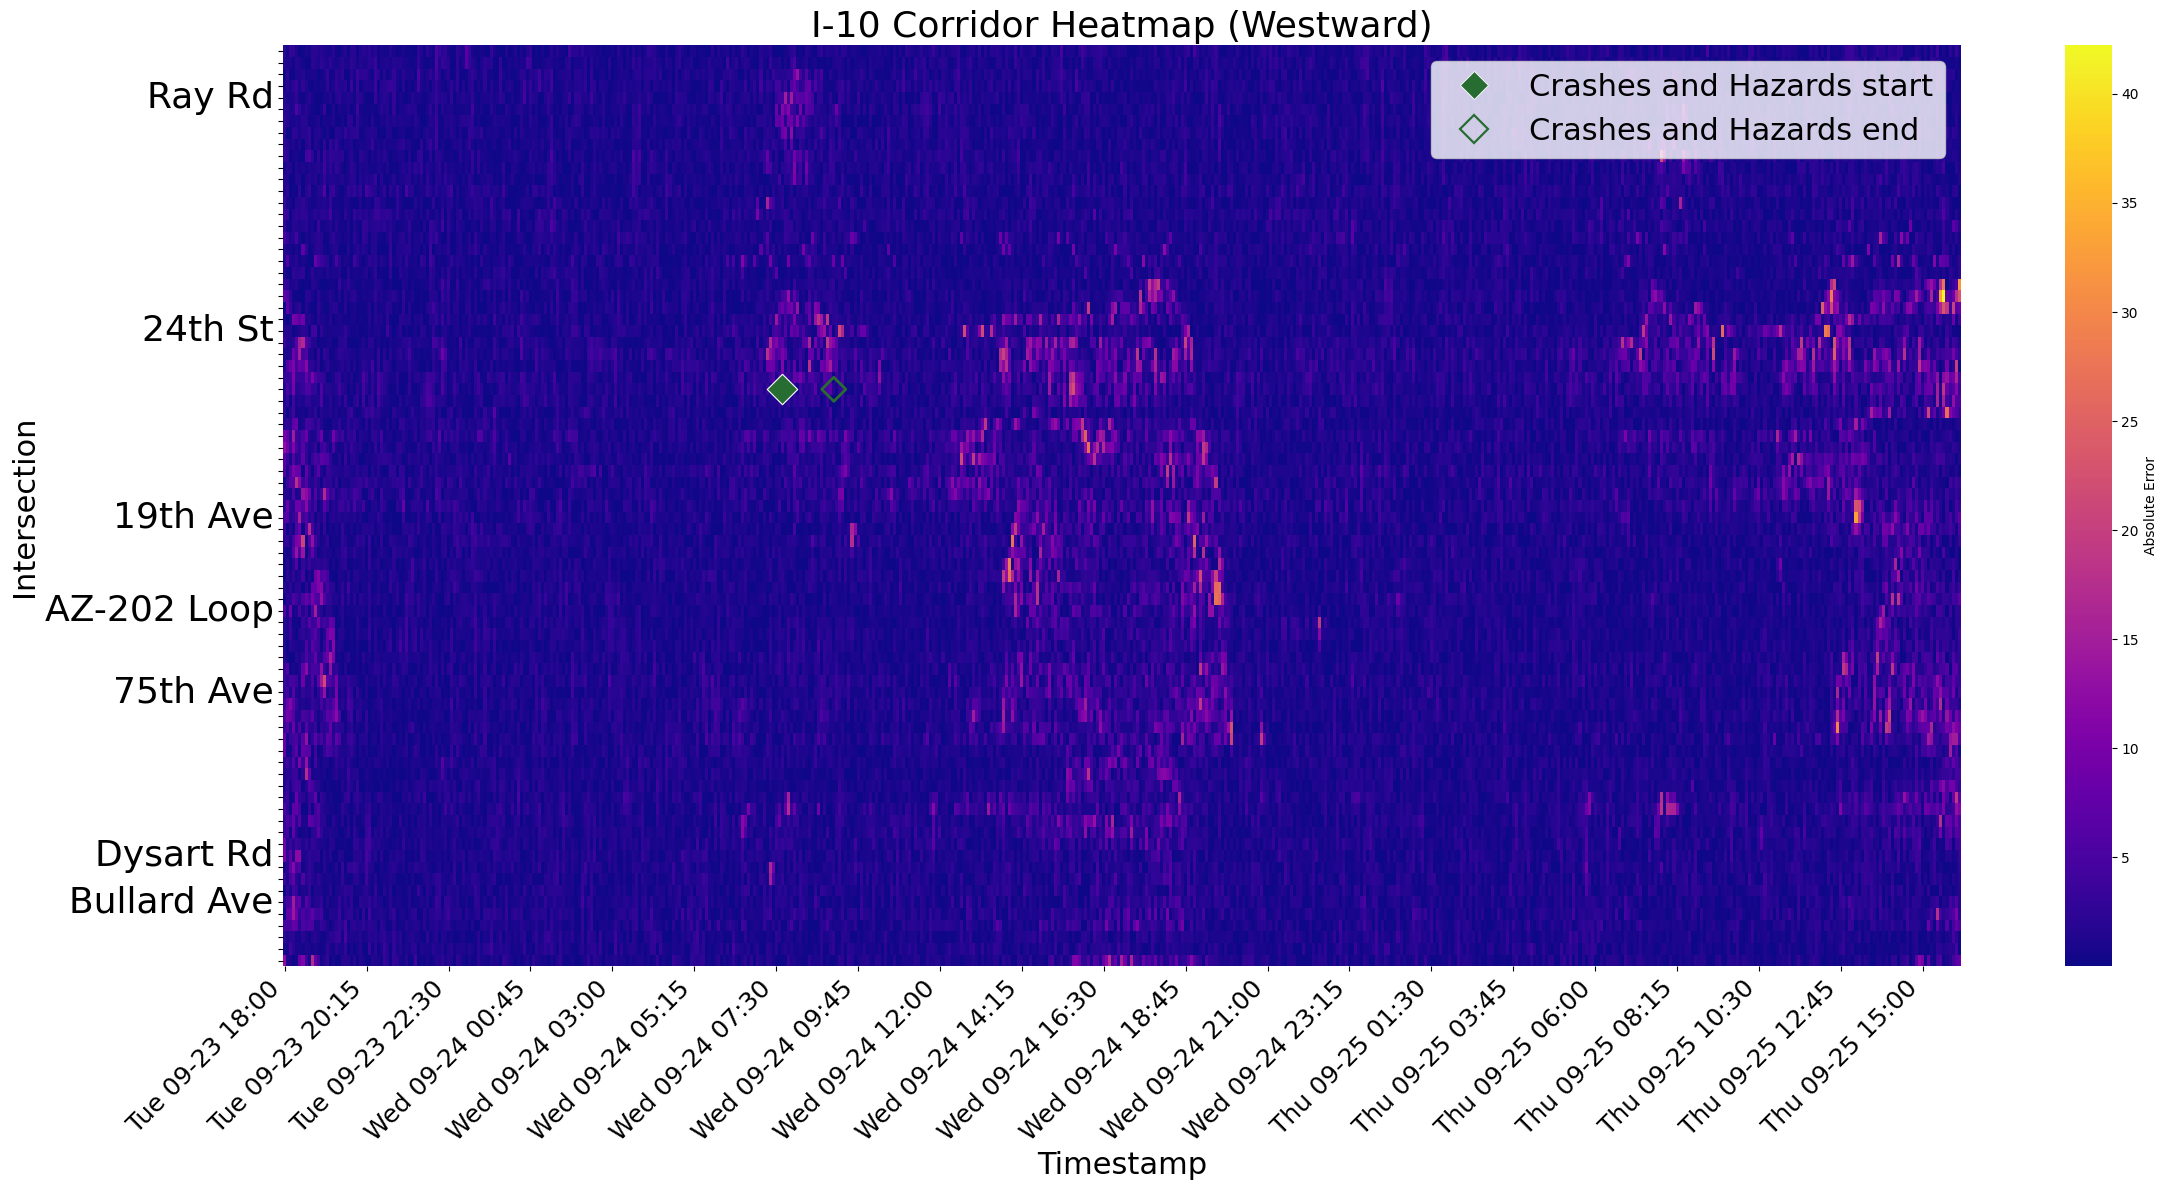

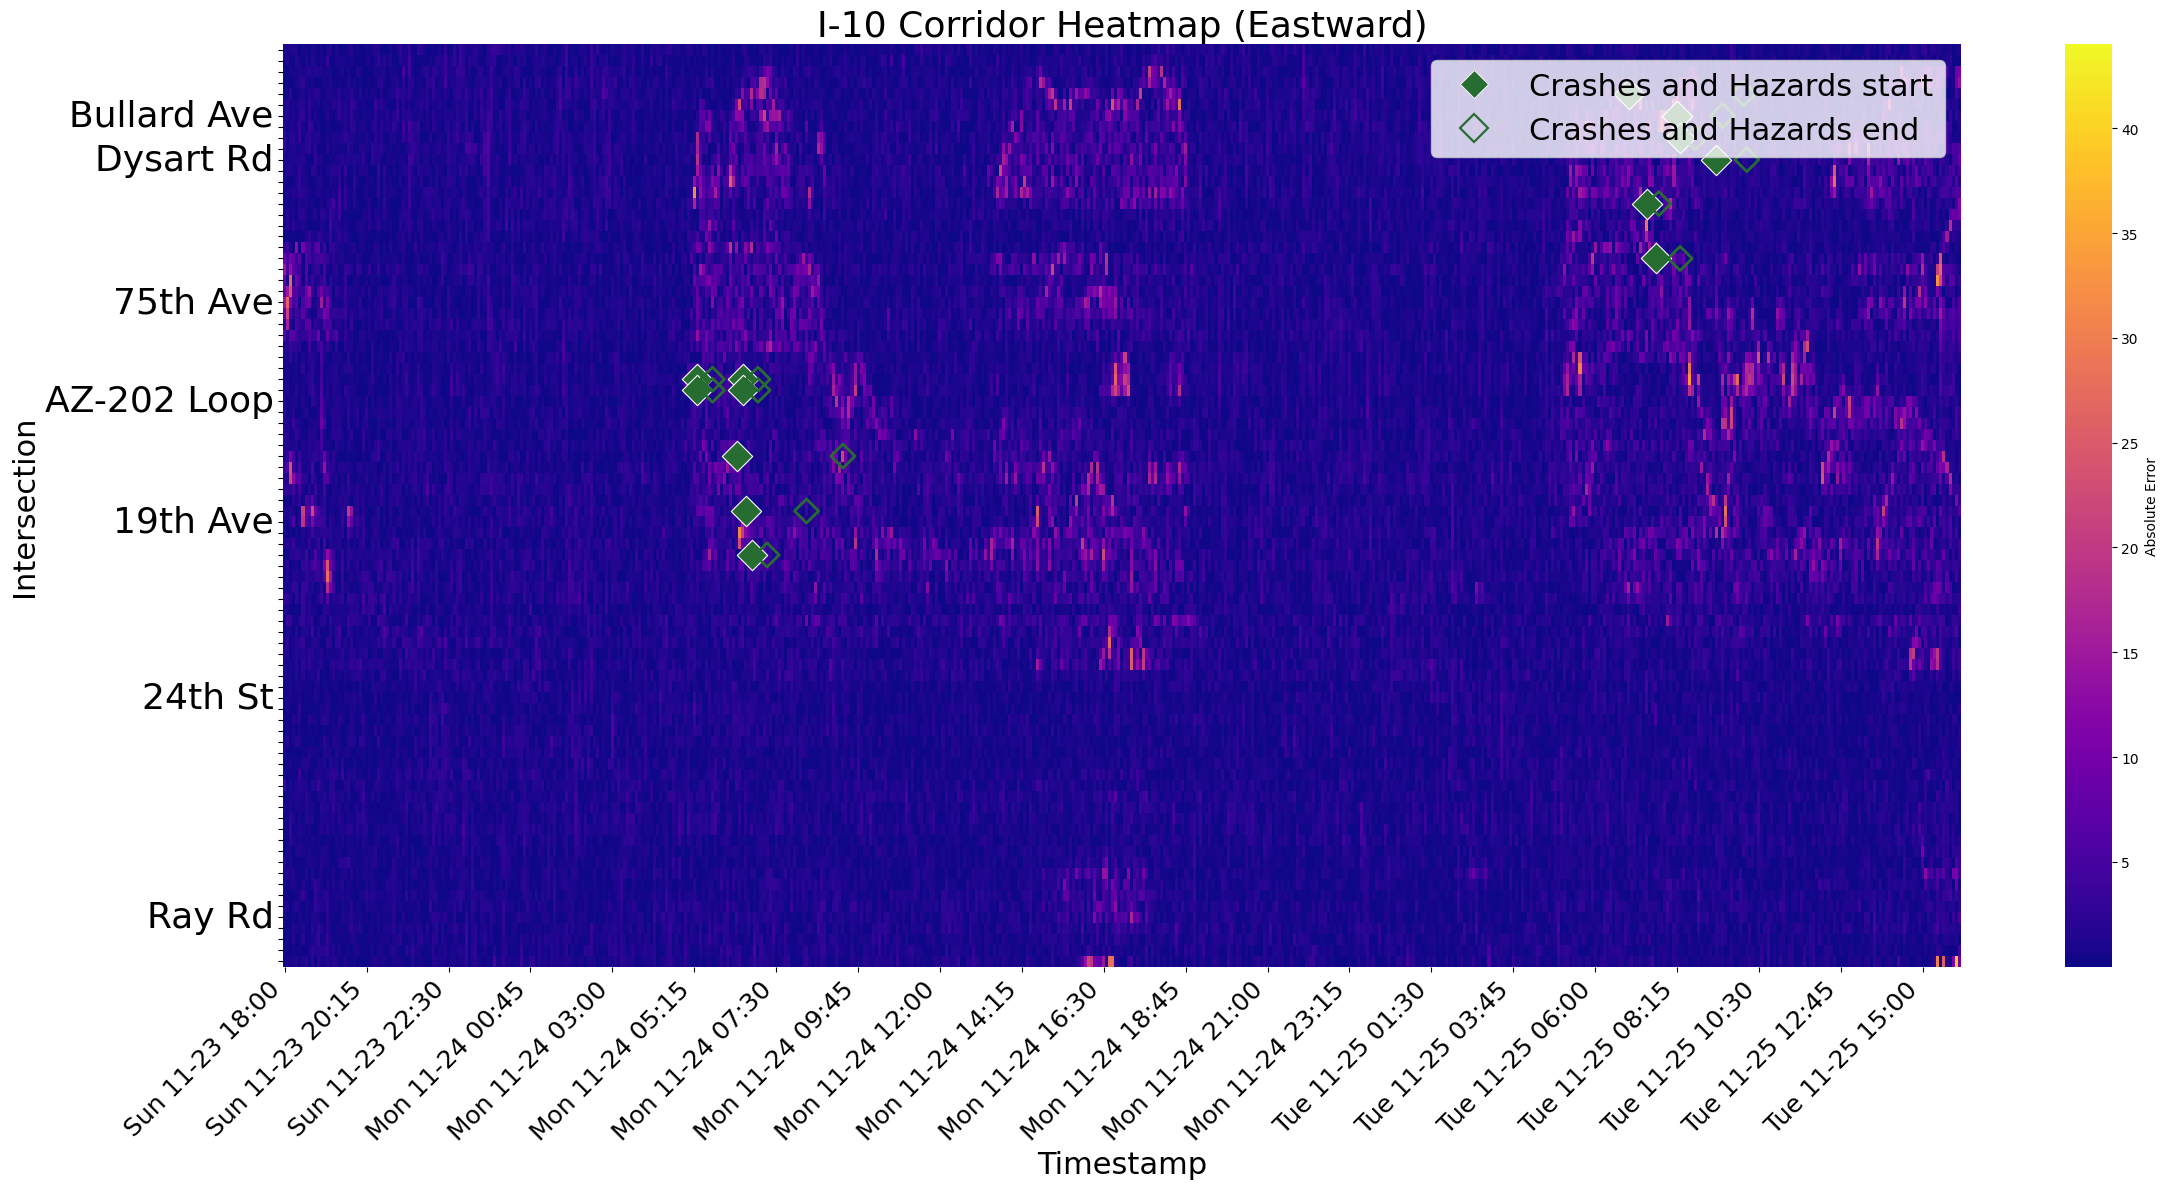

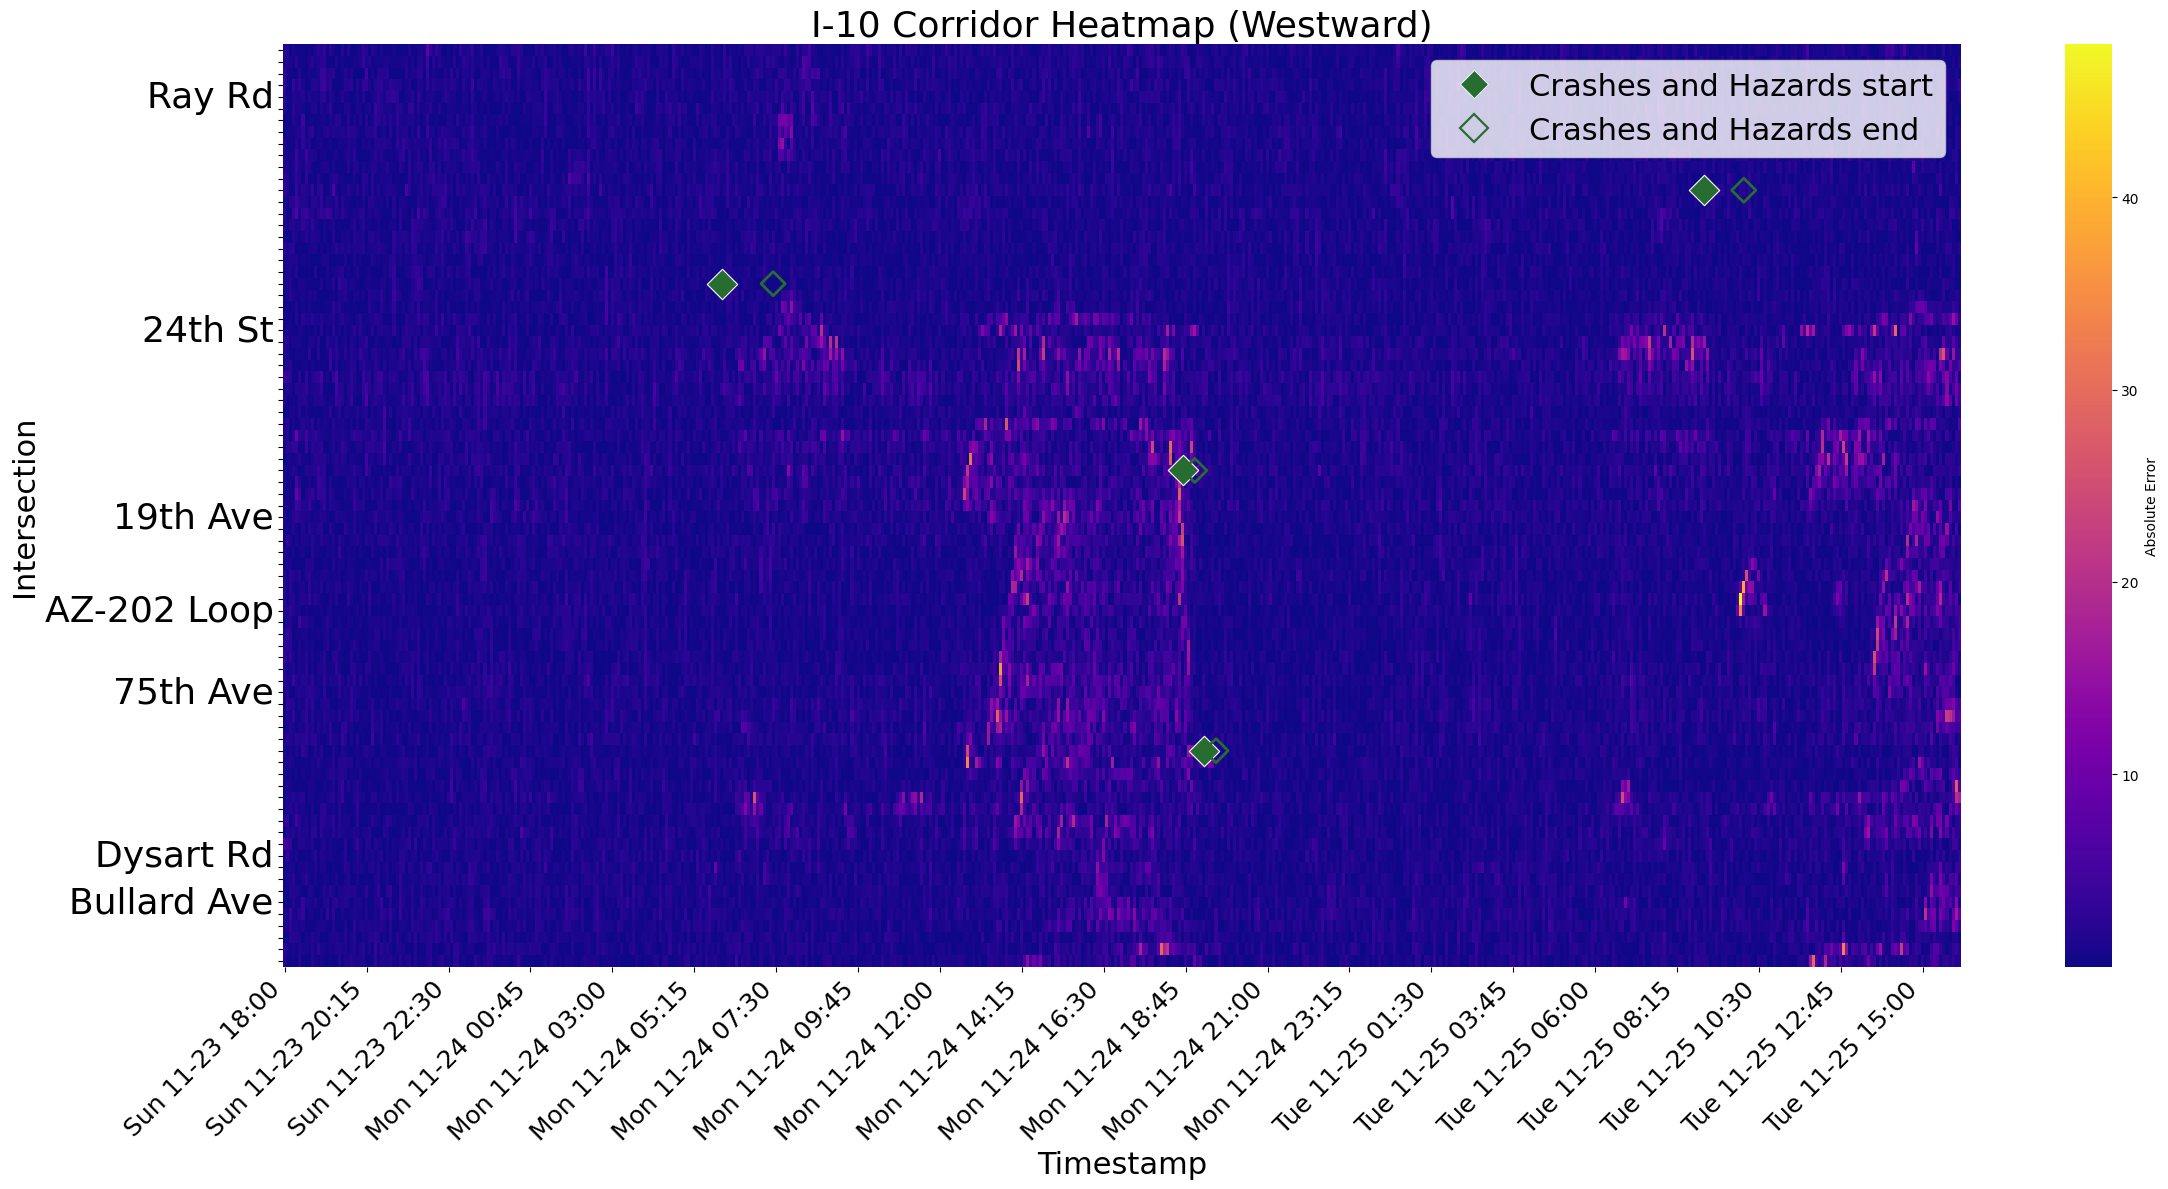

In [11]:
# Useful views: 'ground_truth', 'prediction', 'error', 'absolute_error'

for output_file in output_files:
    plot_segments_heatmap(
        output_file=output_file,
        view="absolute_error",
        n_points=2400,
        columns=eastward_segments,
        title_suffix="Eastward",
        figsize=(24, 12),
    )
    plot_segments_heatmap(
        output_file=output_file,
        view="absolute_error",
        n_points=2400,
        columns=westward_segments,
        title_suffix="Westward",
        figsize=(24, 12),
    )


In [9]:
def summarize_incident_rmse(output_file):
    ref_df = ref_dfs[output_file]
    pred_df = aligned_outputs[output_file].reindex(ref_df.index)
    incident_mask_df = aligned_incidents[output_file].reindex(ref_df.index).fillna(0)

    valid_columns = ref_df.columns.intersection(pred_df.columns).intersection(incident_mask_df.columns)
    ground_truth = ref_df[valid_columns]
    prediction = pred_df[valid_columns]

    valid_mask = ground_truth.notna() & prediction.notna()
    incident_mask = incident_mask_df[valid_columns].gt(0) & valid_mask
    non_incident_mask = (~incident_mask_df[valid_columns].gt(0)) & valid_mask

    squared_error = (prediction - ground_truth) ** 2

    def masked_rmse(mask):
        masked_values = squared_error.where(mask)
        flattened = masked_values.to_numpy().ravel()
        flattened = flattened[~np.isnan(flattened)]
        return np.sqrt(flattened.mean()) if flattened.size else np.nan

    date_label = ref_df.index.min().tz_convert(ARIZONA_TZ).strftime("%Y-%m-%d")
    return {
        "date": date_label,
        "rmse_during_incident": masked_rmse(incident_mask),
        "rmse_outside_incident": masked_rmse(non_incident_mask),
    }


In [10]:
incident_rmse_table = (
    pd.DataFrame([summarize_incident_rmse(output_file) for output_file in output_files])
    .set_index("date")
    .sort_index()
)

incident_rmse_table = incident_rmse_table[[
    "rmse_during_incident",
    "rmse_outside_incident",
]]

incident_rmse_table.round(3)


,rmse_during_incident,rmse_outside_incident
date,,
2025-06-23,3.091,2.736
2025-06-27,1.535,1.723
2025-09-23,4.381,2.979
2025-11-23,4.695,2.756
